# Turbulent, kinetic energy estimate

Using the vorticity output to estimate the fluctuating velocity field, we can then estimate the kinetic energy.
It would be interesting to asses how well this works by comparing with the estimates from the more rigorous filtering technique.



In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import paicos as pa
import numpy as np
pa.settings.strict_units = False

In [11]:
def get_folder(basefolder, halo, galform, zoom_factor, descr):
    # specials = [417, 20, 542]  # Special cases
    # if halo in specials:
    #     descr += '_special'
    zoom = zoom_factor
    if galform is True:
        phys = 'gal-form'
    elif galform == 'tng':
        phys = 'tng'
    elif galform == 'dark':
        phys = 'dark'
    else:
        phys = 'adiabatic-mhd'
        
    if basefolder[-1] != '/':
        basefolder += '/'
    
    return basefolder + f"halo_{halo:04d}/{phys}/zoom{zoom}{descr}/"

def get_simfolder(halo, galform='tng', zoom_factor=12, descr=''):
    basefolder = '/llust21/cosmo-plasm/zoom-simulations-arepo2'
    folder = get_folder(basefolder, halo=halo, galform=galform, zoom_factor=zoom_factor, descr=descr)
    return folder

In [12]:
simfolder = get_simfolder(4)
snap = pa.Snapshot(simfolder + 'output', 304, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
R200c = snap.Cat.Group['Group_R_Crit200'][0].value
# widths = [10000, 10000, 2*R200c]
widths = [10000, 10000, 0]

# Estimating the fluctuating velocity
Here comes the actual new code

In [67]:
def Vorticity(snap, get_dependencies=False):
    """ Returns the vorticity."""

    if get_dependencies:
        return ['0_VelocityGradient']

    def get_index(ii, jj):
        return ii * 3 + jj
    gradV = snap['0_VelocityGradient']
    vorticity = np.zeros(snap['0_VelocityGradient'].shape[0], 3)

    if pa.settings.use_units:
        vorticity = vorticity * gradV.uq
    vorticity[:, 0] = gradV[:, get_index(2, 1)] - gradV[:, get_index(1, 2)]
    vorticity[:, 1] = gradV[:, get_index(0, 2)] - gradV[:, get_index(2, 0)]
    vorticity[:, 2] = gradV[:, get_index(1, 0)] - gradV[:, get_index(0, 1)]

    return vorticity


def VelocityDivergence(snap, get_dependencies=False):
    """ Returns the divergence of the velocity."""

    if get_dependencies:
        return ['0_VelocityGradient']

    def get_index(ii, jj):
        return ii * 3 + jj
    gradV = snap['0_VelocityGradient']

    divergence = (gradV[:, get_index(0, 0)]
                  + gradV[:, get_index(1, 1)]
                  + gradV[:, get_index(2, 2)])
    return divergence

def FluctuatingVelocityFromVorticity(snap, get_dependencies=False):
    if get_dependencies:
        return ['0_VelocityGradient', '0_Diameters']
        
    fluc_vel = np.zeros_like(snap['0_Velocities'])
    
    gradV = snap['0_VelocityGradient']
    
    def get_index(ii, jj):
        return ii * 3 + jj
    
    # gradV[:, get_index(2, 1)] is \partial v_z / \partial_y
    
    # flux_x  = cell_size (d v_x / dy + d v_x / d_z ) / 2
    # flux_y  = cell_size (d v_y / dx + d v_y / d_z ) / 2
    # flux_z  = cell_size (d v_z / dx + d v_z / d_y ) / 2

#     fluc_vel[:, 0] = (gradV[:, get_index(2, 1)] - gradV[:, get_index(1, 2)]) * snap['0_Diameters']
#     fluc_vel[:, 1] = (gradV[:, get_index(0, 2)] - gradV[:, get_index(2, 0)]) * snap['0_Diameters']
#     fluc_vel[:, 2] = (gradV[:, get_index(1, 0)] - gradV[:, get_index(0, 1)]) * snap['0_Diameters']
    
    fluc_vel[:, 0] = (gradV[:, get_index(0, 1)] + gradV[:, get_index(0, 2)]) / 2 * snap['0_Diameters']
    fluc_vel[:, 1] = (gradV[:, get_index(1, 0)] + gradV[:, get_index(1, 2)]) / 2 * snap['0_Diameters']
    fluc_vel[:, 2] = (gradV[:, get_index(2, 0)] + gradV[:, get_index(2, 1)]) / 2 * snap['0_Diameters']
    
    return fluc_vel


def FluctuatingVelocityFromDivergence(snap, get_dependencies=False):
    if get_dependencies:
        return ['0_VelocityGradient', '0_Diameters']
        
    fluc_vel = np.zeros_like(snap['0_Velocities'])
    
    gradV = snap['0_VelocityGradient']
    
    def get_index(ii, jj):
        return ii * 3 + jj
    
    # gradV[:, get_index(2, 1)] is \partial v_z / \partial_y
    
    # flux_x  = cell_size (d v_x / dy + d v_x / d_z ) / 2
    # flux_y  = cell_size (d v_y / dx + d v_y / d_z ) / 2
    # flux_z  = cell_size (d v_z / dx + d v_z / d_y ) / 2

#     fluc_vel[:, 0] = (gradV[:, get_index(2, 1)] - gradV[:, get_index(1, 2)]) * snap['0_Diameters']
#     fluc_vel[:, 1] = (gradV[:, get_index(0, 2)] - gradV[:, get_index(2, 0)]) * snap['0_Diameters']
#     fluc_vel[:, 2] = (gradV[:, get_index(1, 0)] - gradV[:, get_index(0, 1)]) * snap['0_Diameters']
    
    fluc_vel[:, 0] = (gradV[:, get_index(0, 1)] + gradV[:, get_index(0, 2)]) / 2
    fluc_vel[:, 1] = (gradV[:, get_index(1, 0)] + gradV[:, get_index(1, 2)]) / 2
    fluc_vel[:, 2] = (gradV[:, get_index(2, 0)] + gradV[:, get_index(2, 1)]) / 2
                      
    fluc_vel *= snap['0_Diameters']
    
    return fluc_vel


In [68]:
fluc_vec = FluctuatingVelocityFromVorticity(snap)

In [69]:
fluc_vec

<PaicosQuantity [[108.72353508, -42.59572698, -45.61475049],
                 [-12.94052784,  -6.00217777, -55.17050115],
                 [-17.06034485,  -2.8735504 , -68.90444061],
                 ...,
                 [-37.89585213,  19.21102125,   7.48752578],
                 [-23.01473012,   2.76775597,  73.77715593],
                 [-31.74192972,  59.50831921,  48.21239234]] arepo_velocity small_a(1/2)>

In [70]:
snap['0_Velocities']

<PaicosQuantity [[-548.168396  ,  774.5269165 ,   69.42615509],
                 [-573.45703125,  616.7824707 ,   71.57860565],
                 [-992.19403076,  743.16827393,  357.81185913],
                 ...,
                 [ 559.98242188,  -51.71245575,  486.55493164],
                 [ 712.34283447,  -75.98894501,  509.45620728],
                 [ 689.77288818,  -65.91719818,  665.10125732]] arepo_velocity small_a(1/2)>

In [71]:
E_kin = 1/2 * snap['0_Density'] * np.sum(fluc_vec**2, axis=1).to_physical

In [72]:
v = np.sqrt(np.sum(snap['0_Velocities']**2, axis=1)).to_physical
v_bulk = np.sqrt(np.sum((snap['0_Velocities'] - fluc_vec)**2, axis=1)).to_physical
v_fluc = np.sqrt(np.sum(fluc_vec**2, axis=1)).to_physical

In [73]:
slicer = pa.Slicer(snap, center, widths, 'z', npix=2048)

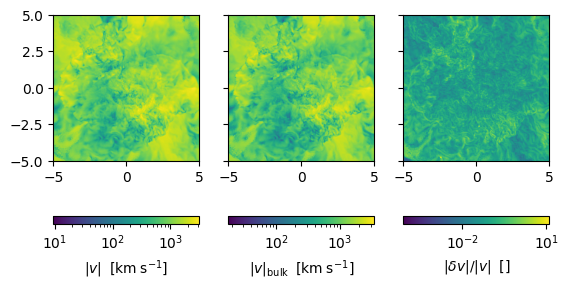

In [74]:
plt.figure(1)
plt.clf()
fig, axes = plt.subplots(num=1, ncols=3, sharey=True)

extent = slicer.centered_extent.to('Mpc')


vals = [v, v_bulk, v_fluc/v]
labels = [r'|v|', r'|v|_\mathrm{bulk}', r'|\delta v| / |v|']

for ii in range(3):
    val = vals[ii]
    label = labels[ii]
    val_slice = slicer.slice_variable(val)
    if ii != 2:
        val_slice = val_slice.to('km/s')
    im = axes[ii].imshow(val_slice.value, origin='lower',
                        extent=extent.value, norm=LogNorm())
    fig.colorbar(im, ax=axes[ii], orientation='horizontal', label=val_slice.label(label))
# Make a plot

# axes[1].imshow(slicer.slice_variable(v_bulk), origin='lower',
#                 extent=extent.value, norm=LogNorm())
# axes[2].imshow(slicer.slice_variable(v_fluc/v), origin='lower',
#                 extent=extent.value, norm=LogNorm())
plt.savefig('halo4_turbulence_v2.png', dpi=1400)
plt.show()